In [1]:
%matplotlib notebook

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import compute_dms as cdms #from compute_dms.py file 
from matplotlib import cm


In [3]:
#use surface functions from 6d_dms_04_5.res
x_param, y_param, z_param, x_pow, y_pow, z_pow = cdms.get_coeffs_powers('6d_dms_04_5.res')
r_eq = cdms.get_non_linear_p('6d_dms_04_5.res')

x_dms = cdms.get_dms(x_param, r_eq, x_pow, 'x')
y_dms = cdms.get_dms(y_param, r_eq, y_pow, 'y')
z_dms = cdms.get_dms(z_param, r_eq, z_pow, 'z')
dms = [x_dms, y_dms, z_dms]

In [4]:
equilibriums = [1.60429226, 1.46833127, 0.96798292, 110.72852741, 113.05478765, 0]
coordinate_lower_bounds = [1.3, 1.22,  0.77, 77, 57, 0] #rpo1 and rpo2 are swapped
coordinate_upper_bounds = [2.4, 2.0, 1.5, 180, 180, 180]

rpo2_grid = np.linspace(1.3, 2.4, 100)
rpo1_grid = np.linspace(1.22, 2.0, 100)
r2_r1_mesh = np.meshgrid(rpo2_grid, rpo1_grid)
rpo2_mesh = r2_r1_mesh[0]
rpo1_mesh = r2_r1_mesh[1]

geometry_r2_r1 = np.zeros((len(rpo2_grid)*len(rpo1_grid), 
                           6) )
geometry_r2_r1[:, 0] = rpo2_mesh.flatten()
geometry_r2_r1[:, 1] = rpo1_mesh.flatten()

for j in range(2,6):
    geometry_r2_r1[:, j] = equilibriums[j]

x_dms_vals = x_dms(geometry_r2_r1)
x_dms_vals = np.reshape(x_dms_vals, 
                        (len(rpo2_grid), len(rpo1_grid)) #shape 
                       )

print(np.shape(x_dms_vals))

(100, 100)


<IPython.core.display.Javascript object>


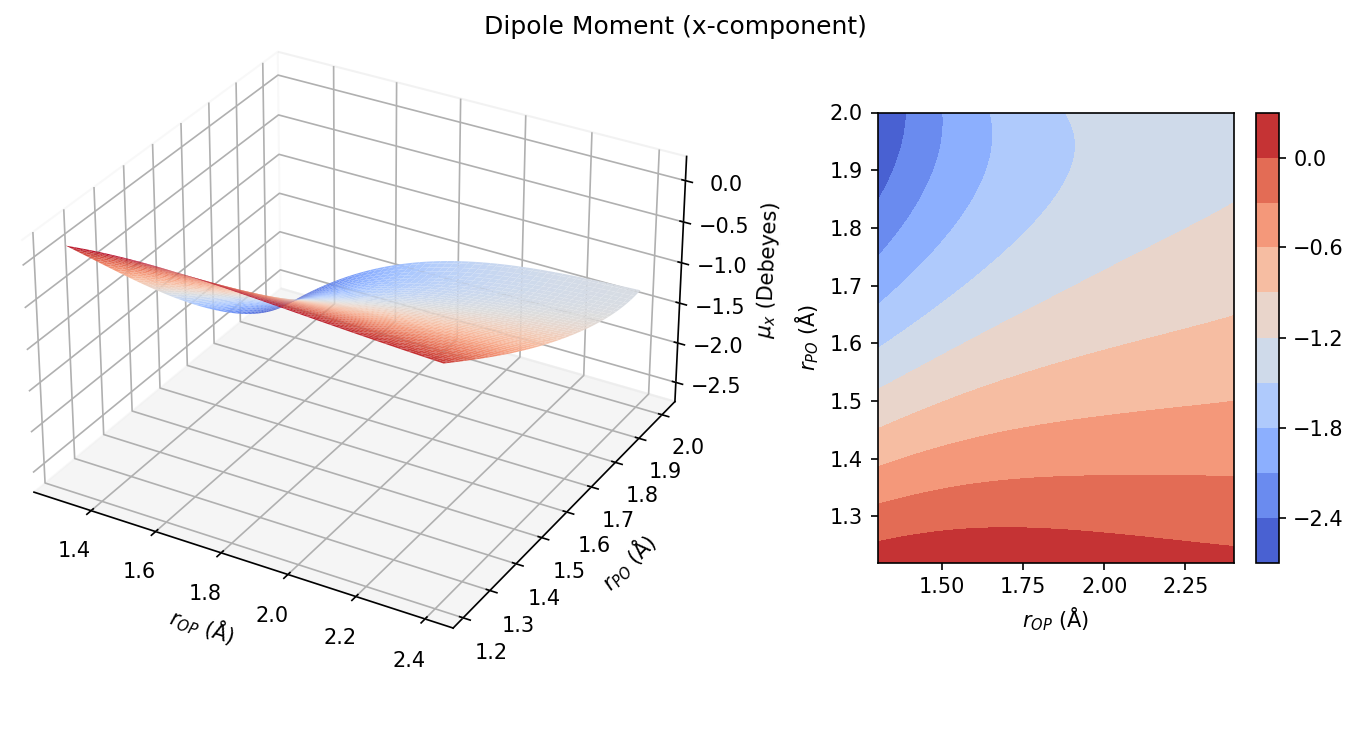

In [5]:
fig = plt.figure(figsize=(9, 5))
fig.suptitle('Dipole Moment (x-component)')
ax_3d = fig.add_axes([-0.1, 0.08, 0.72, 0.95], projection='3d')
#ax_3d = fig.add_subplot(1, 2, 1, projection='3d')
ax_3d.plot_surface(
    rpo2_mesh, rpo1_mesh, x_dms_vals,
    cmap=cm.coolwarm,
    shade=True,           # adds lighting effect
)
ax_3d.set_box_aspect([1,1,0.6]) 
ax_3d.set_xlabel(r'$r_{OP}$ (Å)') #rpo1
ax_3d.set_ylabel(r'$r_{PO}$ (Å)') #rpo2
ax_3d.set_zlabel(r'$\mu_{x}$ (Debeyes)');
ax_3d.axis('tight');

# Remove background panes
ax_3d.xaxis.pane.fill = False
ax_3d.yaxis.pane.fill = False
#ax_3d.zaxis.pane.fill = True

#ax_contour = fig.add_subplot(1, 2, 2, projection=None)
ax_contour = fig.add_axes([0.65, 0.25, 0.33, 0.6])  
contour = ax_contour.contourf(
    rpo2_mesh, rpo1_mesh, x_dms_vals,
    levels=10, #num contour lines
    cmap=cm.coolwarm
)
ax_contour.set_xlabel(r'$r_{OP}$ (Å)') #rpo1
ax_contour.set_ylabel(r'$r_{PO}$ (Å)') #rpo2

plt.colorbar(contour, ax=ax_contour)
plt.show()

In [6]:
apoh_grid = np.linspace(0, 180, 100)
tau_grid = np.linspace(0, 180, 100)

apoh_tau_mesh = np.meshgrid(apoh_grid, tau_grid)
apoh_mesh = apoh_tau_mesh[0]
tau_mesh = apoh_tau_mesh[1]

geometry_apoh_tau = np.zeros((len(apoh_grid)*len(tau_grid), 
                           6) )
geometry_apoh_tau[:, 4] = apoh_mesh.flatten()
geometry_apoh_tau[:, 5] = tau_mesh.flatten()

for j in range(4):
    geometry_apoh_tau[:, j] = equilibriums[j]
    
x_dms_vals = x_dms(geometry_apoh_tau)
x_dms_vals = np.reshape(x_dms_vals, 
                        (len(apoh_grid), len(tau_grid)) #shape 
                       )

<IPython.core.display.Javascript object>


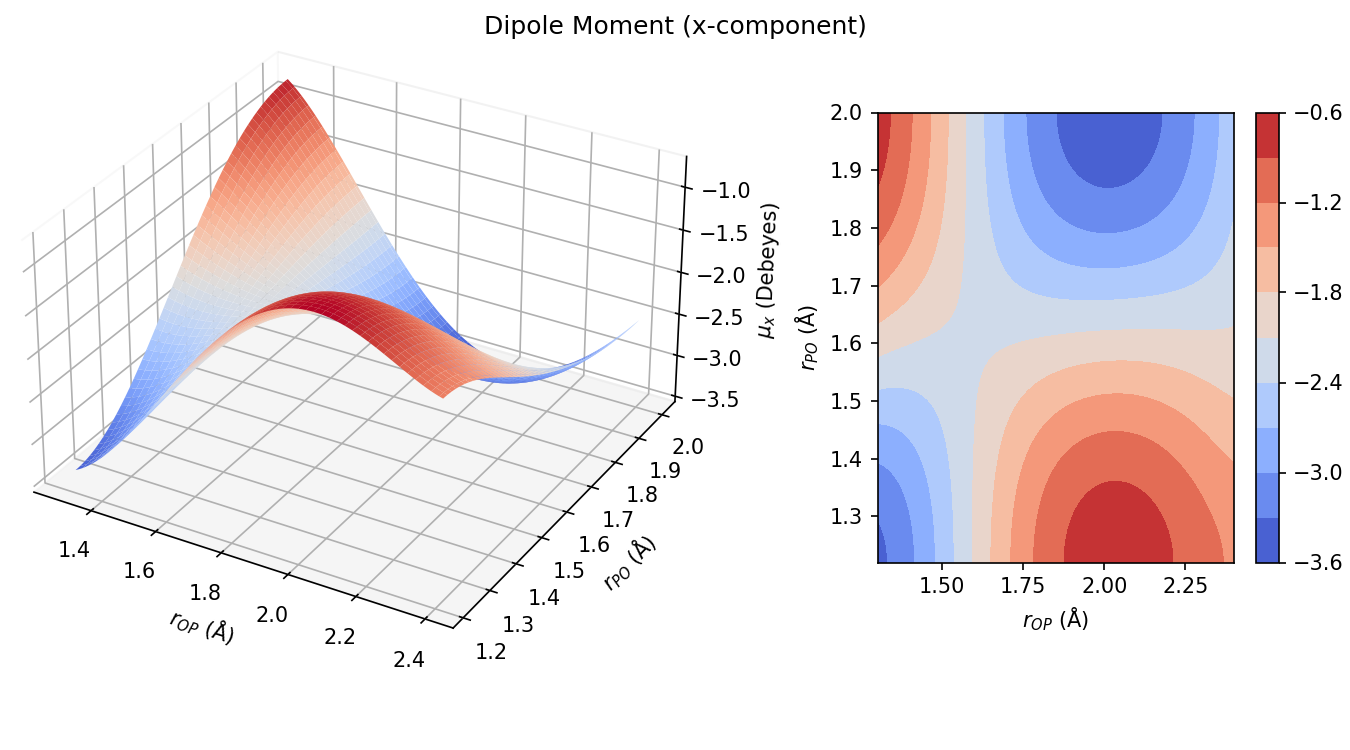

In [10]:
fig = plt.figure(figsize=(9, 5))
fig.suptitle('Dipole Moment (x-component)')
ax_3d = fig.add_axes([-0.1, 0.08, 0.72, 0.95], projection='3d')
#ax_3d = fig.add_subplot(1, 2, 1, projection='3d')
ax_3d.plot_surface(
    rpo2_mesh, rpo1_mesh, x_dms_vals,
    cmap=cm.coolwarm,
    shade=True,           # adds lighting effect
)
ax_3d.set_box_aspect([1,1,0.6]) 
ax_3d.set_xlabel(r'$r_{OP}$ (Å)') #rpo1
ax_3d.set_ylabel(r'$r_{PO}$ (Å)') #rpo2
ax_3d.set_zlabel(r'$\mu_{x}$ (Debeyes)');
ax_3d.axis('tight');

# Remove background panes
ax_3d.xaxis.pane.fill = False
ax_3d.yaxis.pane.fill = False
#ax_3d.zaxis.pane.fill = True

#ax_contour = fig.add_subplot(1, 2, 2, projection=None)
ax_contour = fig.add_axes([0.65, 0.25, 0.33, 0.6])  
contour = ax_contour.contourf(
    rpo2_mesh, rpo1_mesh, x_dms_vals,
    levels=10, #num contour lines
    cmap=cm.coolwarm
)
ax_contour.set_xlabel(r'$r_{OP}$ (Å)') #rpo1
ax_contour.set_ylabel(r'$r_{PO}$ (Å)') #rpo2

plt.colorbar(contour, ax=ax_contour)
plt.show()